In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\thana\Desktop\flight_analysis\data\flight_ml_ready.csv")

print("Γραμμές:", len(df))
print("Έτοιμο!")

Γραμμές: 1928371
Έτοιμο!


In [3]:
features = [
    "Month_sin", "Month_cos",
    "DayOfWeek", "IS_WEEKEND",
    "CRSDepTime", "Distance",
    "CarrierDelay", "NASDelay"
]

le = LabelEncoder()
df["Carrier_encoded"] = le.fit_transform(df["UniqueCarrier"])
features.append("Carrier_encoded")

X = df[features]
y = df["DELAYED"]

print("X shape:", X.shape)

X shape: (1928371, 9)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1542696
Test size: 385675


In [5]:
# Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),   # 3 layers
    activation="relu",
    solver="adam",
    max_iter=50,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("=== Neural Network ===")
print(classification_report(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:,1]))

Iteration 1, loss = 0.40073629
Iteration 2, loss = 0.38423200
Iteration 3, loss = 0.37913887
Iteration 4, loss = 0.37654989
Iteration 5, loss = 0.37494956
Iteration 6, loss = 0.37366406
Iteration 7, loss = 0.37233281
Iteration 8, loss = 0.37126394
Iteration 9, loss = 0.37044237
Iteration 10, loss = 0.36978166
Iteration 11, loss = 0.36935427
Iteration 12, loss = 0.36860697
Iteration 13, loss = 0.36817836
Iteration 14, loss = 0.36768963
Iteration 15, loss = 0.36710647
Iteration 16, loss = 0.36670701
Iteration 17, loss = 0.36649736
Iteration 18, loss = 0.36617548
Iteration 19, loss = 0.36585508
Iteration 20, loss = 0.36567053
Iteration 21, loss = 0.36540976
Iteration 22, loss = 0.36520132
Iteration 23, loss = 0.36500801
Iteration 24, loss = 0.36475420
Iteration 25, loss = 0.36459567
Iteration 26, loss = 0.36456074
Iteration 27, loss = 0.36441733
Iteration 28, loss = 0.36428258
Iteration 29, loss = 0.36408555
Iteration 30, loss = 0.36403163
Iteration 31, loss = 0.36397832
Iteration 32, los

c:\Users\thana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


=== Neural Network ===
              precision    recall  f1-score   support

           0       0.81      0.91      0.86    219579
           1       0.86      0.72      0.78    166096

    accuracy                           0.83    385675
   macro avg       0.84      0.82      0.82    385675
weighted avg       0.83      0.83      0.83    385675

ROC-AUC: 0.9006010794615074


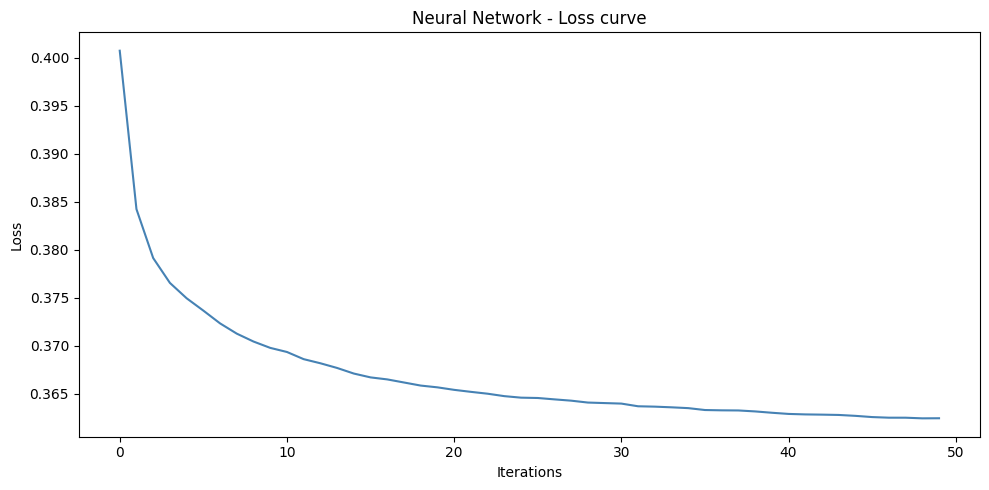

In [6]:
# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, color="steelblue")
plt.title("Neural Network - Loss curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

| Μοντέλο | Accuracy | F1(avg) | ROC-AUC |
|--------:|:--------:|:-------:|--------:|
|NN - MLP| 83% | 0.82 | 0.901 |